# 중고차 가격 예측을 위한 데이터 전처리 파이프라인
- Target: price

- Strategy: 완전 관측 데이터(Complete-case) 기반 비례 층화 추출 및 스케일링/인코딩

## 라이브러리 로드 및 데이터 불러오기

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from google.colab import drive
import os

# 경고 메시지 무시
import warnings
warnings.filterwarnings('ignore')

# 드라이브 마운팅
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/DS_TP/vehicles.csv'

# 1. 원본 데이터 불러오기(파일을 직접 불러올경우)
#file_path = 'vehicles.csv'

if os.path.exists(file_path):
    # 대용량 파일이므로 로딩 시간을 확인하기 위해 출력문을 추가합니다.
    df = pd.read_csv(file_path)
    print(f"✔️ 원본 데이터 로드 완료! 데이터 크기: {df.shape}")
else:
    print("❌ 파일을 찾을 수 없습니다. 경로를 다시 확인해주세요.")
    print(f"입력한 경로: {file_path}")


print(f"✔️ 원본 데이터 크기: {df.shape}")

Mounted at /content/drive
✔️ 원본 데이터 로드 완료! 데이터 크기: (426880, 26)
✔️ 원본 데이터 크기: (426880, 26)


## Step 1. 불필요한 피처 제거

In [ ]:
# 1. 가격 예측에 불필요하거나 신뢰할 수 없는 Feature 제거
columns_to_drop = [
    'id', 'url', 'image_url',                 # 고유 식별자 및 URL
    'region', 'region_url', 'lat', 'long', 'state', # 위치 정보
    'county',                                 # 100% 결측치
    'size',                                    # 80% 결측치 및 임의 추가 데이터
    'description'                           # 주관적 견해가 들어간 비정형 데이터
]

df_step1 = df.drop(columns=columns_to_drop, errors='ignore')
print(f"✔️ 열 제거 후 데이터 크기: {df_step1.shape}")

✔️ 열 제거 후 데이터 크기: (426880, 15)


## Step 2. 결측치 행 전부 제거 - User 전략

In [ ]:
# 2. 결측치가 하나라도 포함된 레코드(행) 전부 제거
# (빈칸이 없는 완벽하게 깨끗한 데이터만 남김)
df_step2 = df_step1.dropna()

print(f"✔️ 결측치 행 전체 제거 후 데이터 크기: {df_step2.shape}")
# 보통 이 단계에서 40만 개 중 약 8~12만 개 정도가 남게 됩니다.

✔️ 결측치 행 전체 제거 후 데이터 크기: (61005, 15)


## Step 3. 이상치 제거 - Outlier Detection

In [ ]:
# 3. 도메인 지식을 활용한 이상치 필터링
# 크롤링 연도(2021) 기준 20년 이상 된 차량 제외 -> 2001년식 이상만 남김
condition_price = (df_step2['price'] >= 1000) & (df_step2['price'] <= 1000000)
condition_odometer = (df_step2['odometer'] <= 300000)
condition_year = (df_step2['year'] >= 2001)

df_step3 = df_step2[condition_price & condition_odometer & condition_year].copy()

print(f"✔️ 이상치 필터링 후 데이터 크기: {df_step3.shape}")

✔️ 이상치 필터링 후 데이터 크기: (54805, 15)


## Step 4. 파생 변수 생성

In [ ]:
# 4. 차량 나이(Vehicle Age) 변수 생성 및 year 제거
# posting_date를 활용한 정밀한 차량 나이(Age) 계산

# 시계열 데이터 처리
df_step3['posting_date'] = pd.to_datetime(df_step3['posting_date'], utc=True)

df_step3['vehicle_age'] = df_step3['posting_date'].dt.year - df_step3['year']

# posting_date, year는 vehicle_age와 다중공선성을 가지므로 모델에서 제거
df_step4 = df_step3.drop(columns=['posting_date', 'year'])

print("✔️ 파생 변수 'vehicle_age' 생성 완료 (게시일자 기준)")
display(df_step4[['vehicle_age', 'price', 'odometer']].head(3))

✔️ 파생 변수 'vehicle_age' 생성 완료 (게시일자 기준)


,vehicle_age,price,odometer
32,9.0,27990,68696.0
33,5.0,34590,29499.0
35,5.0,29990,17302.0


In [ ]:
pd.set_option('display.max_rows', None)
print(df_step4['transmission'].value_counts(dropna=False))

transmission
automatic    41287
other        11577
manual        1941
Name: count, dtype: int64
["'other'", "'automatic'", "'manual'"]


## 중간 데이터셋 뽑기

In [ ]:
vehicles_v2 = 'vehicles_v2.csv'
df_step4.to_csv(vehicles_v2, index=False)

## Step 5. 비례 층화 추출을 통한 샘플링
- 전처리 Step 5 (2,000개로 샘플링) 직후에, 살아남은 2,000개의 VIN 번호를 루프 돌려서 LLM API를 호출하고 original_msrp 열을 만들어 붙이는 코드가 추가되어야 함.


In [ ]:
# 5. 타겟 변수(price) 분위수 분할 기반 층화 샘플링 (목표: 2,000개)
SAMPLE_SIZE = 2000

# 5개의 분위수로 가격대 분할 (Equal Frequency Binning)
df_step4['price_tier'] = pd.qcut(df_step4['price'], q=5, labels=['Tier1', 'Tier2', 'Tier3', 'Tier4', 'Tier5'])

# 각 Tier(구간)에서 400개씩 균등하게 추출하여 총 2,000개 샘플링
df_sampled = df_step4.groupby('price_tier', group_keys=False).apply(
    lambda x: x.sample(n=int(SAMPLE_SIZE/5), random_state=42)
).copy()

# 샘플링 완료 후 필요 없는 임시 변수 삭제
df_sampled.drop(columns=['price_tier'], inplace=True)

# 인덱스 초기화
df_sampled.reset_index(drop=True, inplace=True)

print(f"✔️ 비례 층화 샘플링 완료! 최종 학습용 데이터 크기: {df_sampled.shape}")

✔️ 비례 층화 샘플링 완료! 최종 학습용 데이터 크기: (2000, 14)


## Step 6. 범주형 변수 인코딩

In [ ]:
# 6. 범주형 데이터 인코딩 (Label & One-Hot Encoding)

# [1] Label Encoding: 서열이 있는 condition
condition_mapping = {
    'salvage': 0,
    'fair': 1,
    'good': 2,
    'excellent': 3,
    'like new': 4,
    'new': 5
}
df_sampled['condition'] = df_sampled['condition'].map(condition_mapping)

# [2] 기통 수(cylinders) 숫자 추출
# "8 cylinders" -> 8 로 수치만 추출 ('other' 등의 텍스트는 NaN 처리 후 제거)
df_sampled['cylinders'] = df_sampled['cylinders'].astype(str).str.extract(r'(\d+)').astype(float)
df_sampled.dropna(subset=['cylinders'], inplace=True) # 추출 안된 'other' 데이터 제거

# [3] One-Hot Encoding: 서열이 없는 범주형 변수들
cols_to_ohe = ['cylinders', 'manufacturer', 'fuel', 'transmission', 'type', 'title_status', 'drive', 'paint_color']
# (VIN, description 등 텍스트 열은 학습을 위해 잠시 제외하거나 텍스트 마이닝용으로 따로 빼둡니다)

# 모델 학습용 최종 데이터프레임 생성 (텍스트 열 제거 및 원핫 인코딩 적용)
cols_to_drop_for_model = ['VIN', 'model', 'description']
df_encoded = df_sampled.drop(columns=cols_to_drop_for_model, errors='ignore')

# pd.get_dummies를 통한 원-핫 인코딩 수행
# drop_first=True: 더미 변수 함정(다중공선성 문제)'을 막기 위해 기준 열 하나를 자동으로 지워주는 머신러닝의 필수 테크닉
df_encoded = pd.get_dummies(df_encoded, columns=cols_to_ohe, drop_first=True, dtype=int)

print(f"✔️ 인코딩 완료 후 피처(열) 개수: {df_encoded.shape[1]}개")

✔️ 인코딩 완료 후 피처(열) 개수: 78개


## Step 7. 수치형 데이터 스케일링

In [ ]:
# 7. 수치형 변수 StandardScaler 적용
scaler = StandardScaler()

# 스케일링 대상: 가격, 주행거리, 차량나이
num_cols = ['price', 'odometer', 'vehicle_age']

# 스케일링 진행
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

print("✔️ 수치형 데이터 스케일링(StandardScaler) 완료!")
print("\n--- 전처리 완료된 최종 데이터프레임 샘플 ---")
display(df_encoded.head(3))

✔️ 수치형 데이터 스케일링(StandardScaler) 완료!

--- 전처리 완료된 최종 데이터프레임 샘플 ---


,price,condition,odometer,vehicle_age,cylinders_4.0,cylinders_5.0,cylinders_6.0,cylinders_8.0,cylinders_10.0,manufacturer_alfa-romeo,...,paint_color_brown,paint_color_custom,paint_color_green,paint_color_grey,paint_color_orange,paint_color_purple,paint_color_red,paint_color_silver,paint_color_white,paint_color_yellow
0,-1.040346,3,0.273969,-0.202998,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,-1.074244,3,1.275355,1.358127,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,-1.036739,2,0.728541,0.466056,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# 전처리 완료 데이터 EDA (사후 검증 시각화)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 스타일 설정
sns.set_theme(style="whitegrid")
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

print("✅ [1. 최종 데이터 기본 정보 확인]")
# df_sampled: 인코딩/스케일링 전, 샘플링 완료된 직관적인 데이터프레임
display(df_sampled.info())

print("\n✅ [2. 수치형 데이터 통계 요약]")
# 가격, 주행거리, 차량 나이의 평균, 최소/최댓값 등 확인
display(df_sampled[['price', 'odometer', 'vehicle_age']].describe().round(2))

✅ [1. 최종 데이터 기본 정보 확인]
<class 'pandas.core.frame.DataFrame'>
Index: 1994 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         1994 non-null   int64  
 1   manufacturer  1994 non-null   object 
 2   model         1994 non-null   object 
 3   condition     1994 non-null   int64  
 4   cylinders     1994 non-null   float64
 5   fuel          1994 non-null   object 
 6   odometer      1994 non-null   float64
 7   title_status  1994 non-null   object 
 8   transmission  1994 non-null   object 
 9   VIN           1994 non-null   object 
 10  drive         1994 non-null   object 
 11  type          1994 non-null   object 
 12  paint_color   1994 non-null   object 
 13  vehicle_age   1994 non-null   float64
dtypes: float64(3), int64(2), object(9)
memory usage: 233.7+ KB


None


✅ [2. 수치형 데이터 통계 요약]


,price,odometer,vehicle_age
count,1994.00,1994.00,1994.00
mean,20791.60,88083.40,7.91
std,13308.14,57081.26,4.49
min,1000.00,0.00,0.00
25%,9500.00,36528.75,4.00
50%,17900.00,85240.00,7.00
75%,30990.00,127123.75,11.00
max,120000.00,296041.00,20.00


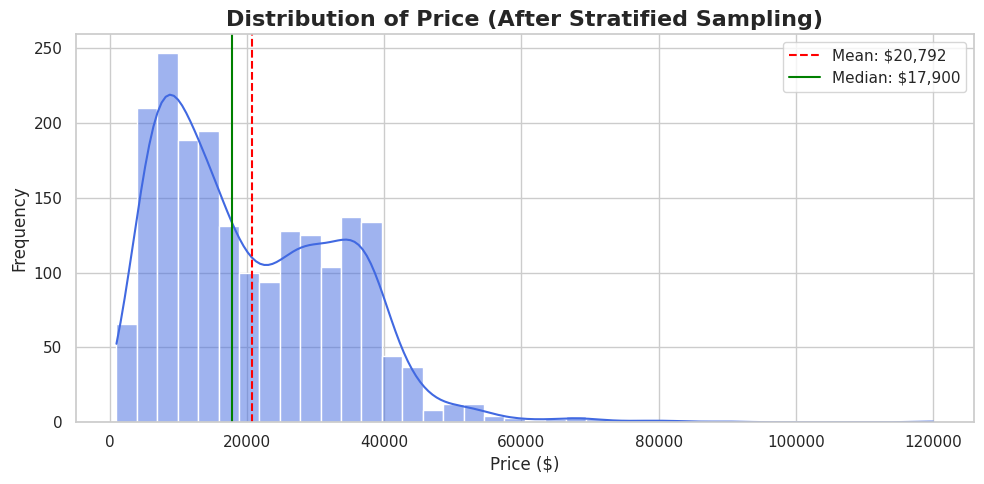

In [ ]:
# 1. 샘플링 후 타겟 변수(Price) 분포 확인
# -> 2,000개로 줄였음에도 '우측으로 꼬리가 긴(Right-skewed)' 형태가 유지되었는지 검증

plt.figure(figsize=(10, 5))
sns.histplot(df_sampled['price'], bins=40, kde=True, color='royalblue')
plt.title("Distribution of Price (After Stratified Sampling)", fontsize=16, fontweight='bold')
plt.xlabel("Price ($)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# 평균과 중앙값 표시
plt.axvline(df_sampled['price'].mean(), color='red', linestyle='--', label=f"Mean: ${df_sampled['price'].mean():,.0f}")
plt.axvline(df_sampled['price'].median(), color='green', linestyle='-', label=f"Median: ${df_sampled['price'].median():,.0f}")

plt.legend()
plt.tight_layout()
plt.show()

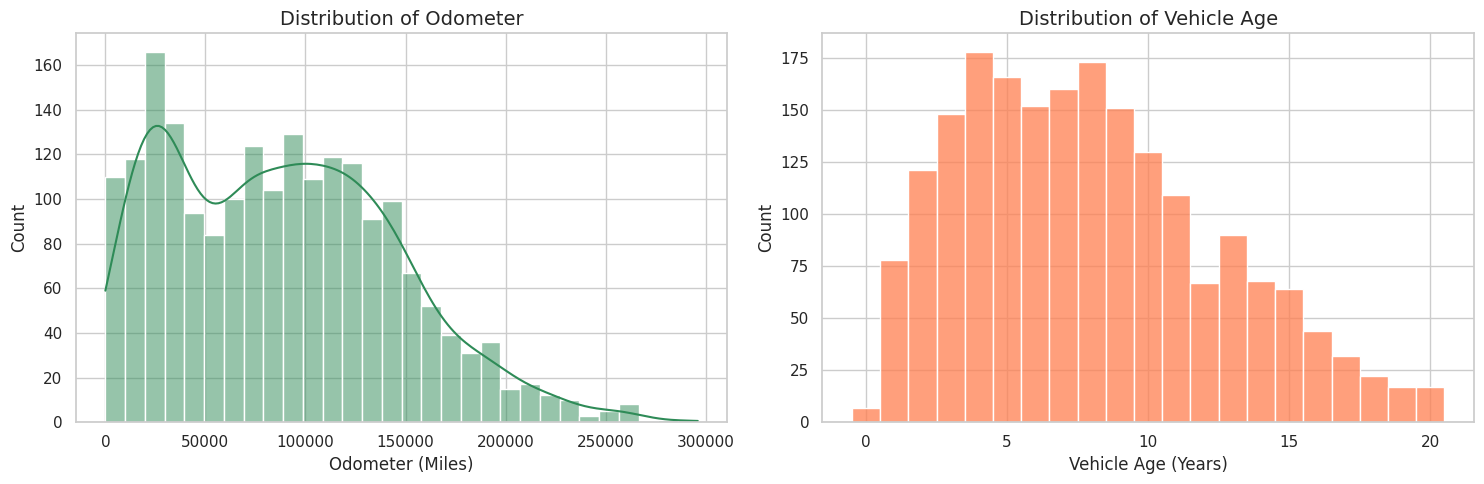

In [ ]:
# 2. 주행거리(Odometer)와 차량 나이(Vehicle Age) 분포

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 주행거리 분포
sns.histplot(df_sampled['odometer'], bins=30, kde=True, ax=axes[0], color='seagreen')
axes[0].set_title("Distribution of Odometer", fontsize=14)
axes[0].set_xlabel("Odometer (Miles)")
axes[0].set_ylabel("Count")

# 차량 나이 분포
sns.histplot(df_sampled['vehicle_age'], bins=20, kde=False, ax=axes[1], color='coral', discrete=True)
axes[1].set_title("Distribution of Vehicle Age", fontsize=14)
axes[1].set_xlabel("Vehicle Age (Years)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

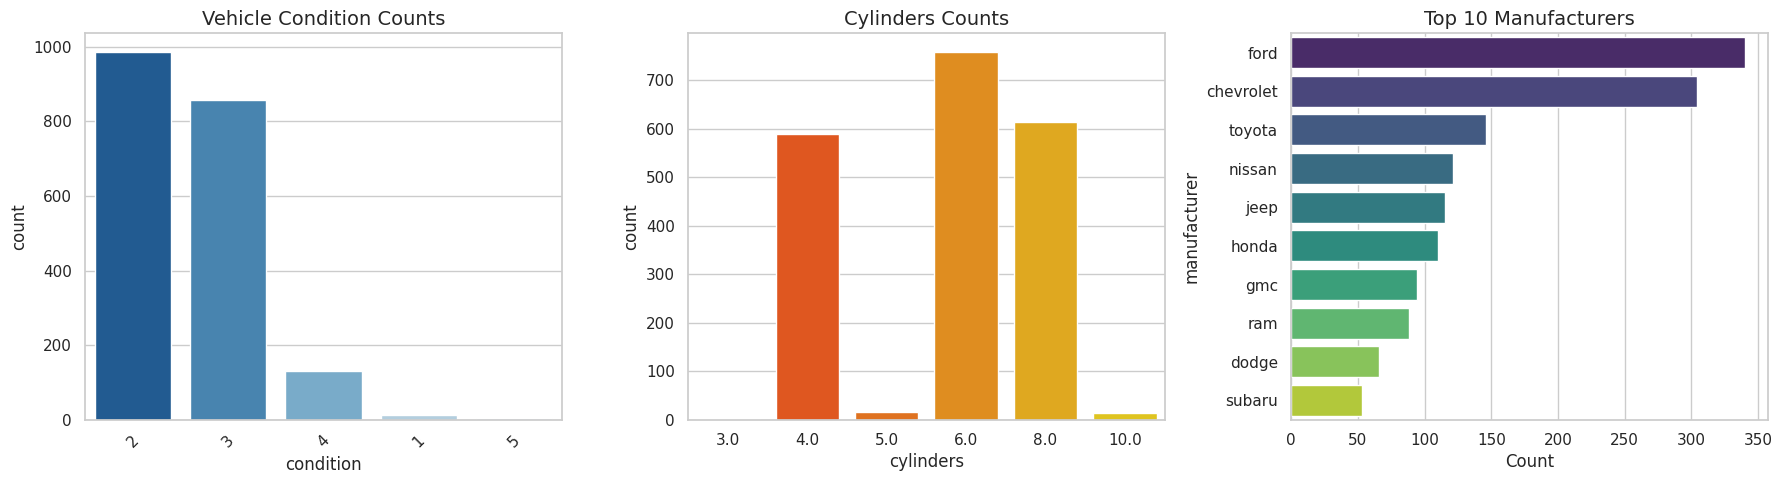

In [ ]:
# 3. 범주형 변수(Condition, Cylinders, Top 10 Manufacturers) 시각화

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3-1. 차량 상태(Condition) 분포
sns.countplot(data=df_sampled, x='condition', ax=axes[0], palette='Blues_r',
              order=df_sampled['condition'].value_counts().index)
axes[0].set_title("Vehicle Condition Counts", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# 3-2. 기통 수(Cylinders) 분포
# 숫자로 추출된 데이터를 정렬하여 표시
cylinders_order = sorted(df_sampled['cylinders'].dropna().unique())
sns.countplot(data=df_sampled, x='cylinders', ax=axes[1], palette='autumn', order=cylinders_order)
axes[1].set_title("Cylinders Counts", fontsize=14)

# 3-3. 상위 10개 제조사(Manufacturer) 분포
top_10_manufacturers = df_sampled['manufacturer'].value_counts().nlargest(10).index
sns.countplot(data=df_sampled, y='manufacturer', ax=axes[2], palette='viridis', order=top_10_manufacturers)
axes[2].set_title("Top 10 Manufacturers", fontsize=14)
axes[2].set_xlabel("Count")

plt.tight_layout()
plt.show()

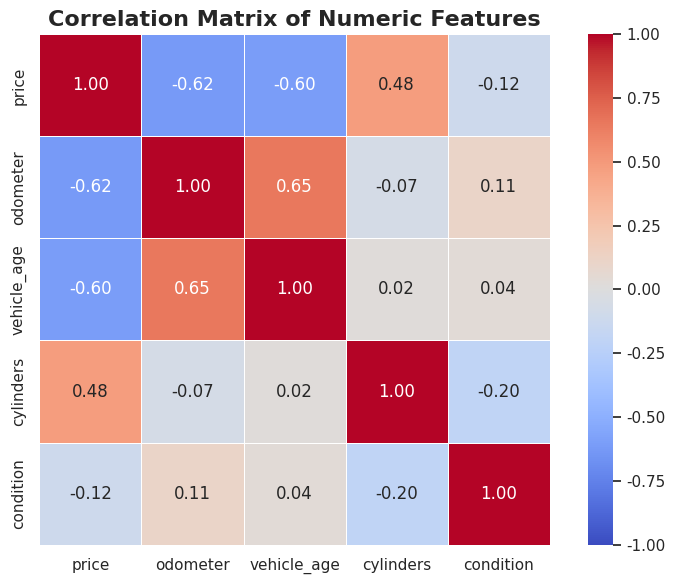

In [ ]:
# 4. 수치형 변수 간의 피어슨 상관계수 (Correlation Matrix)
# 이 히트맵을 통해 주행거리, 차량 나이가 가격과 얼마나 강한 '음(-)'의 상관관계를 갖는지 증명합니다.

# 스케일링/인코딩이 완료된 df_encoded 데이터프레임을 사용할 수도 있지만,
# 해석의 직관성을 위해 df_sampled의 수치형 컬럼만 뽑아서 계산합니다.
numeric_cols = ['price', 'odometer', 'vehicle_age', 'cylinders', 'condition']
corr_matrix = df_sampled[numeric_cols].corr()

plt.figure(figsize=(8, 6))
# annot=True로 실제 상관계수 수치를 표기, cmap='coolwarm'으로 양/음의 관계를 뚜렷하게 표현
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
plt.title("Correlation Matrix of Numeric Features", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()